# Trabajo Práctico de Modelos Predictivos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Usamos StratifiedKFold para mantener las proporciones entre letras
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import string

In [2]:
letras_df = pd.read_csv('TP02-EnglishTypeAlphabet.csv')

## Funciones
Definimos las funciones que se utilizarán en clasificación binaria

In [3]:
# Para evaluar distintas cantidades de atributos y K's
def evaluar_y_mostrar_knn(lista_de_atributos, k):
    columnas = ['pixel ' + str(atributo) for atributo in lista_de_atributos]
    clasificador = KNeighborsClassifier(n_neighbors=k)
    clasificador.fit(X_train[columnas].values, y_train.values)
    y_pred = clasificador.predict(X_test[columnas].values)
    exactitud = accuracy_score(y_test.values, y_pred)
    matriz = confusion_matrix(y_test.values, y_pred)
    print('*'*25,
        f"knn con pixeles {lista_de_atributos} y k={k}",
        f"Exactitud: {round(exactitud, 3)}",
        "matriz de confusion:",
        matriz,
        '_'*25,
        sep='\n')
    return (exactitud, matriz)

# Para evaluar con valores de k en el rango (1, 50)
def evaluar_distintos_k(pixeles):
    lista_k = []
    lista_exactitud = []

    for k in range(1, 51):
        exactitud, matriz = evaluar_y_mostrar_knn(pixeles, k)
        lista_k.append(k)
        lista_exactitud.append(exactitud)

    plt.figure(figsize=(10, 6))
    plt.plot(lista_k, lista_exactitud, marker='o')
    plt.title('Exactitud del modelo KNN para distintos valores de K')
    plt.xlabel('K')
    plt.ylabel('Exactitud (Accuracy)')
    plt.xticks(range(0,51, 5))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Análisis Exploratorio
Primero observamos la cantidad de datos y clases (variantes)

In [4]:
n_filas, n_columnas = letras_df.shape

print(f"Cantidad total de imágenes: {n_filas}")
print(f"Cantidad total de atributos: {n_columnas}")

Cantidad total de imágenes: 26416
Cantidad total de atributos: 785


In [5]:
letras = "abcdefghijklmnopqrstuvwxyz"

for i in range(26):
    cantidad_de_variantes = (letras_df['label'] == i).sum()
    print(f"La letra {letras[i]} ({i}) tiene {cantidad_de_variantes} variantes")


La letra a (0) tiene 1016 variantes
La letra b (1) tiene 1016 variantes
La letra c (2) tiene 1016 variantes
La letra d (3) tiene 1016 variantes
La letra e (4) tiene 1016 variantes
La letra f (5) tiene 1016 variantes
La letra g (6) tiene 1016 variantes
La letra h (7) tiene 1016 variantes
La letra i (8) tiene 1016 variantes
La letra j (9) tiene 1016 variantes
La letra k (10) tiene 1016 variantes
La letra l (11) tiene 1016 variantes
La letra m (12) tiene 1016 variantes
La letra n (13) tiene 1016 variantes
La letra o (14) tiene 1016 variantes
La letra p (15) tiene 1016 variantes
La letra q (16) tiene 1016 variantes
La letra r (17) tiene 1016 variantes
La letra s (18) tiene 1016 variantes
La letra t (19) tiene 1016 variantes
La letra u (20) tiene 1016 variantes
La letra v (21) tiene 1016 variantes
La letra w (22) tiene 1016 variantes
La letra x (23) tiene 1016 variantes
La letra y (24) tiene 1016 variantes
La letra z (25) tiene 1016 variantes


Ahora para cada letra graficamos 5 variantes para visualizar diferencias o similitudes y atributos relevantes

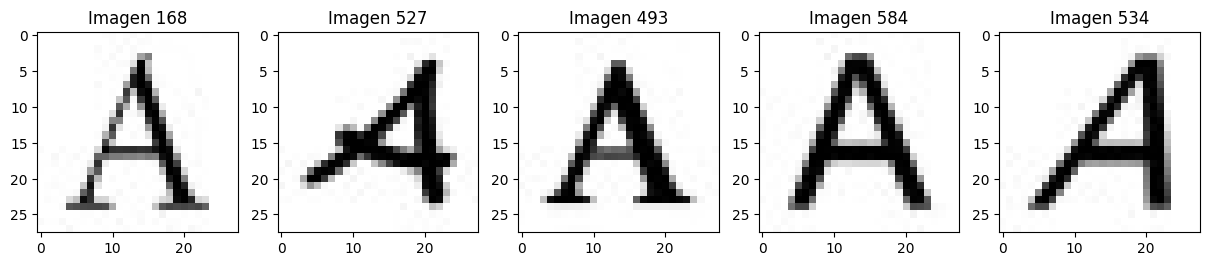

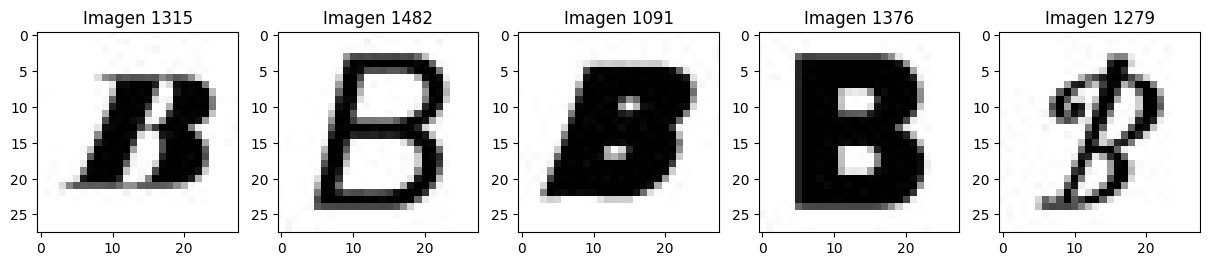

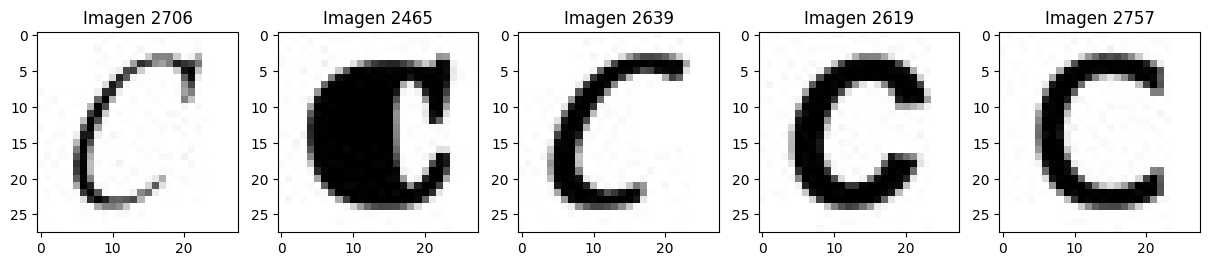

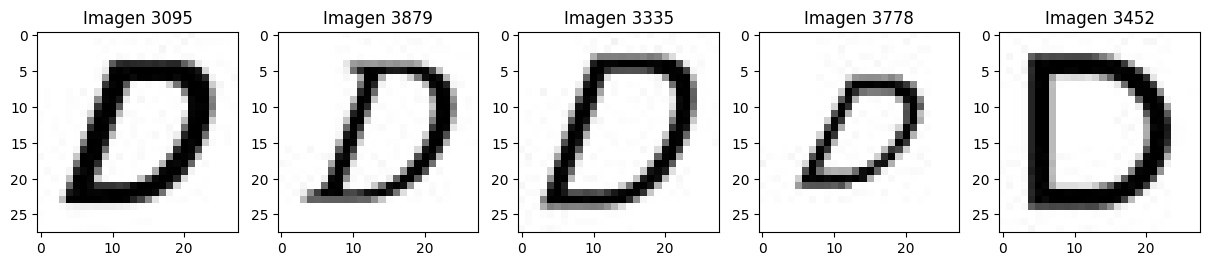

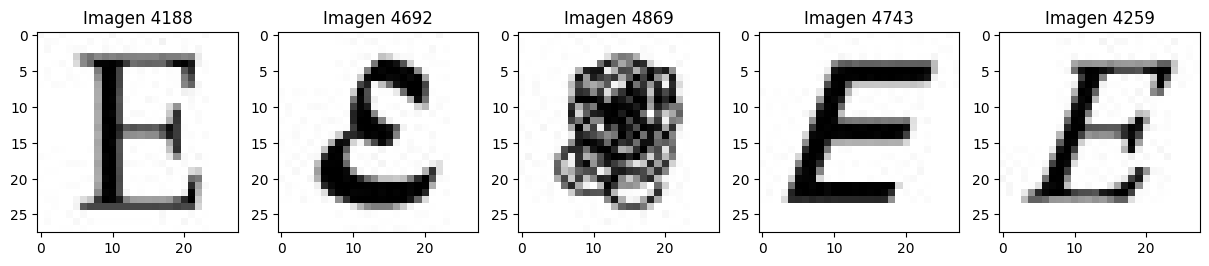

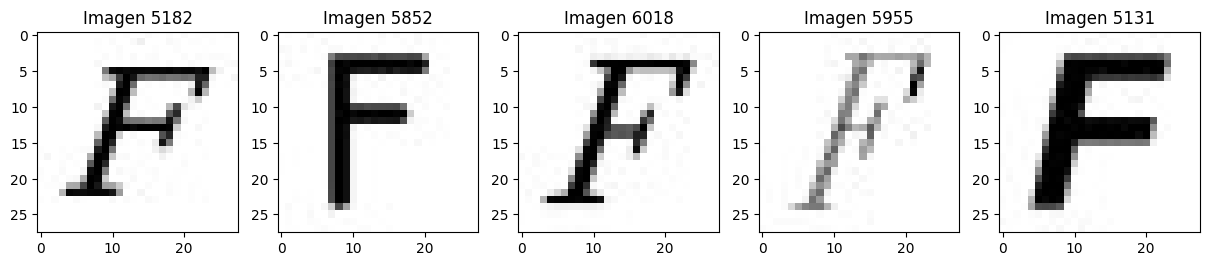

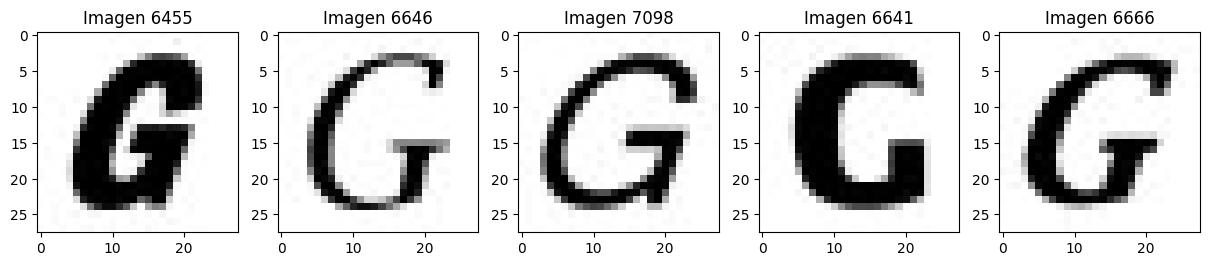

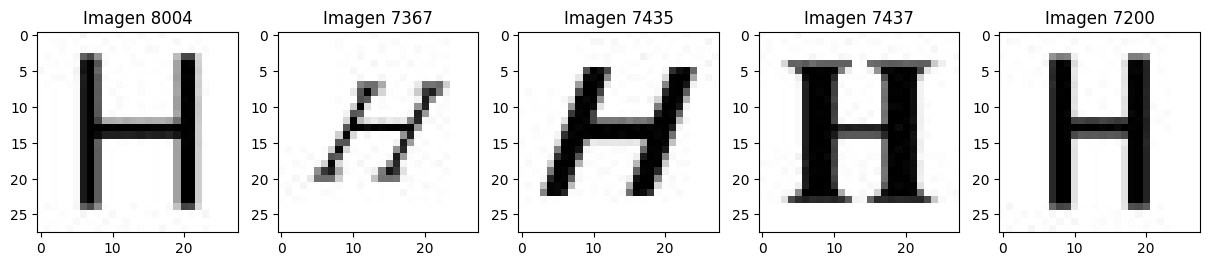

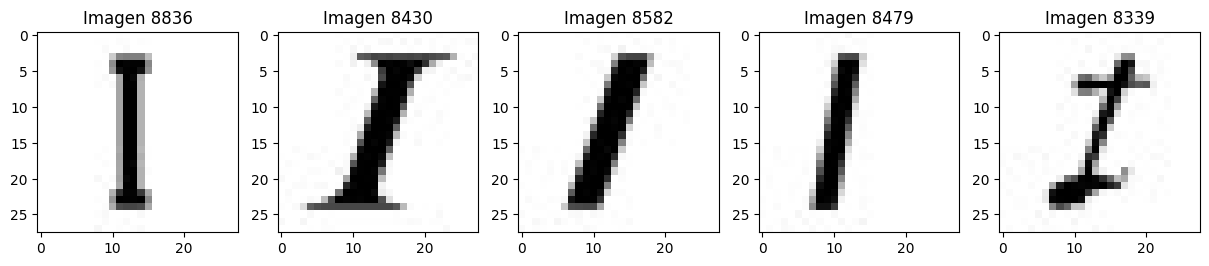

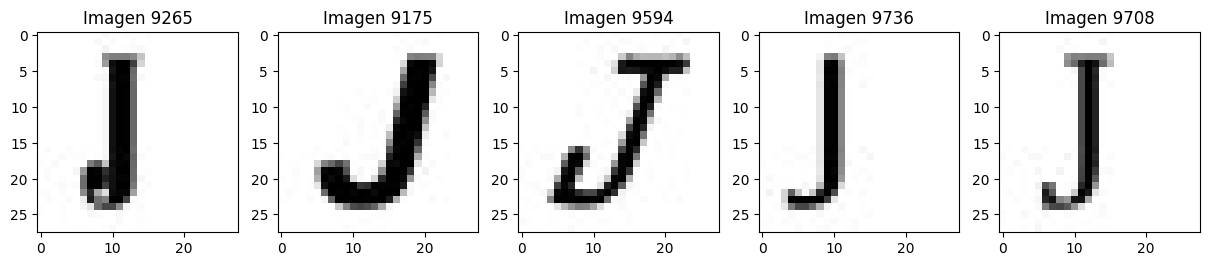

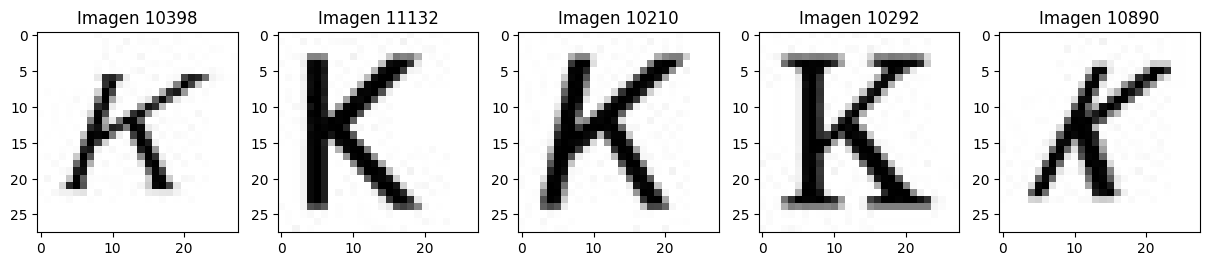

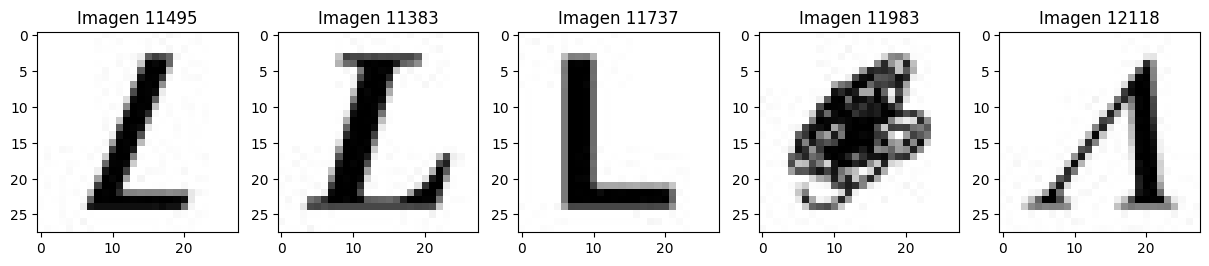

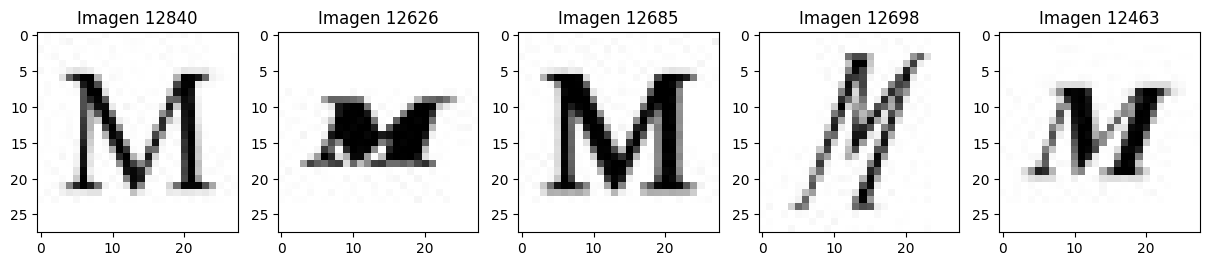

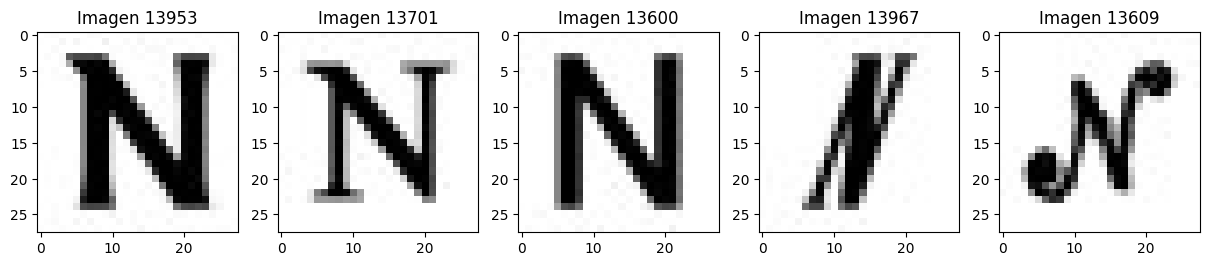

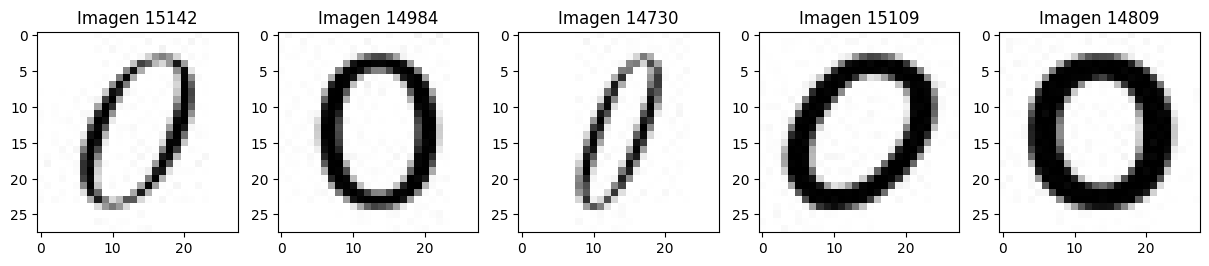

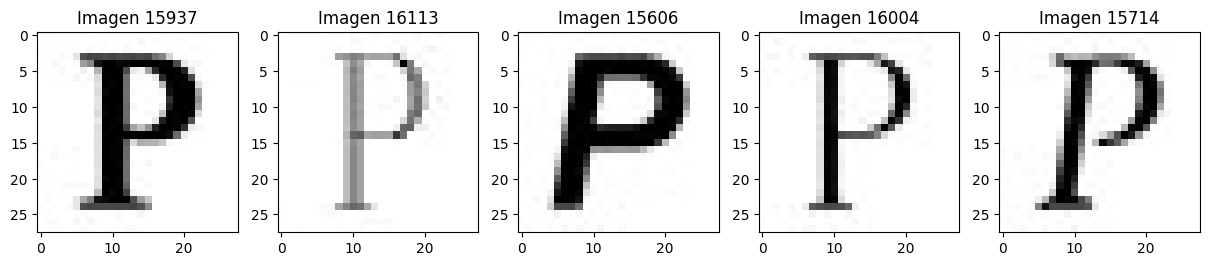

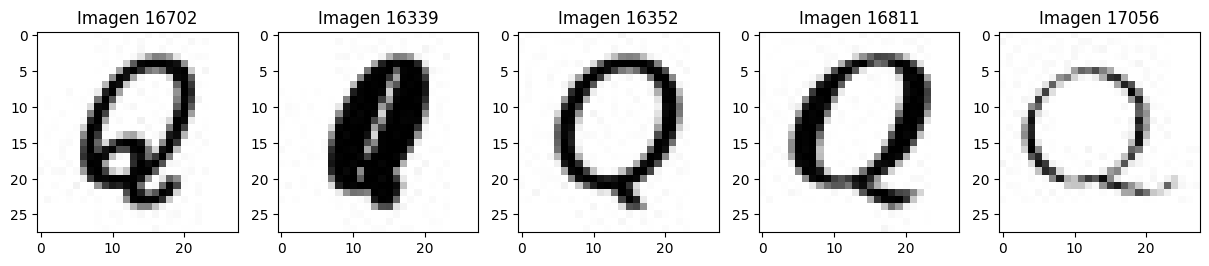

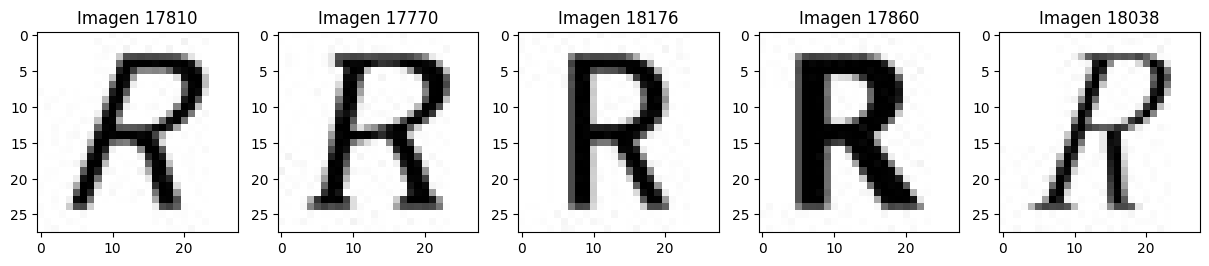

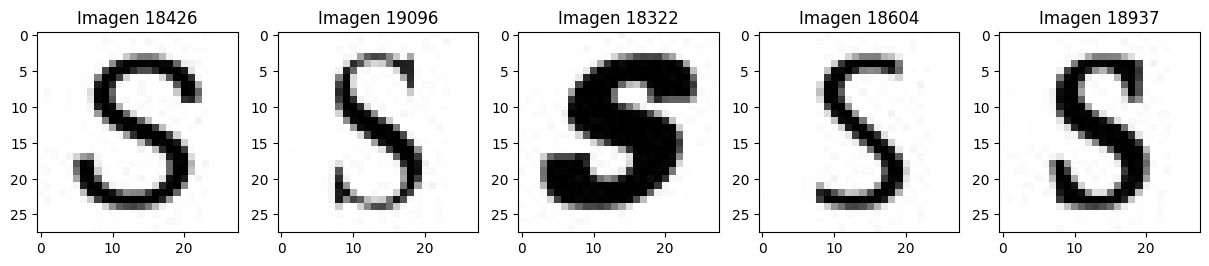

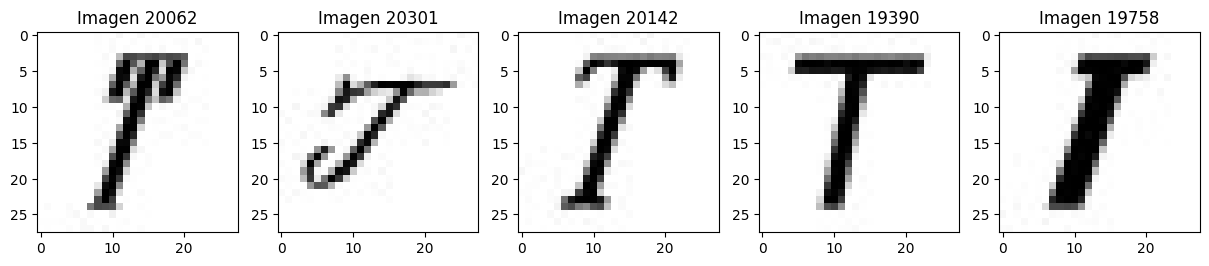

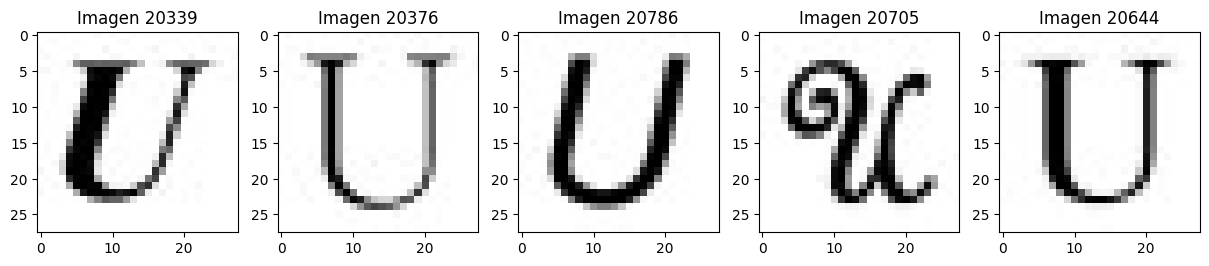

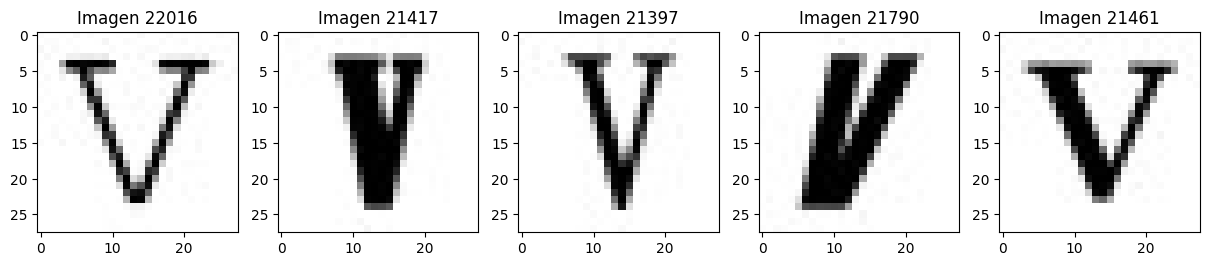

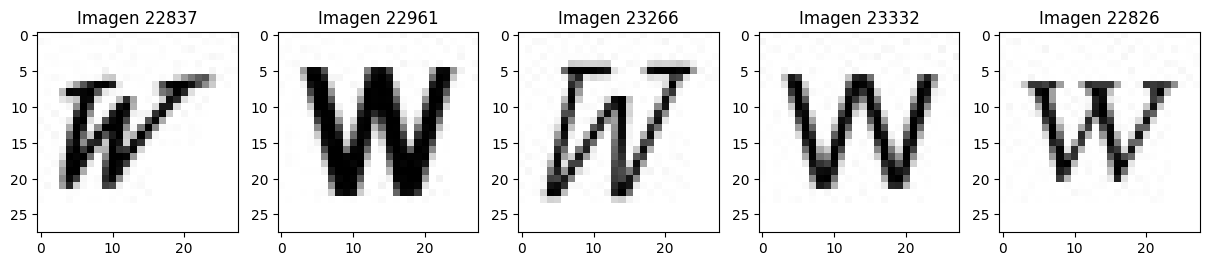

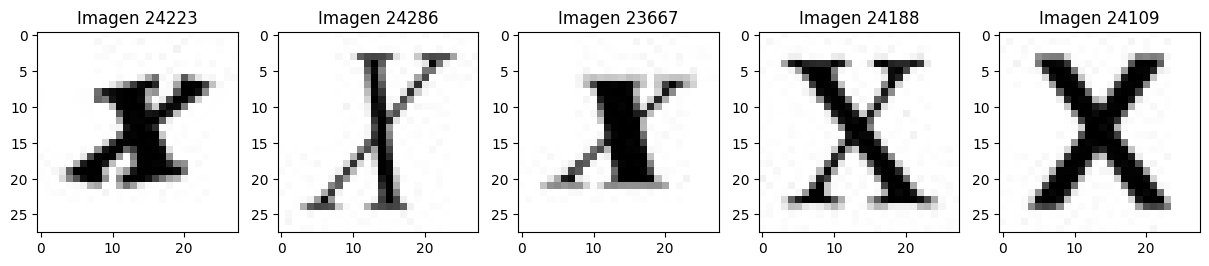

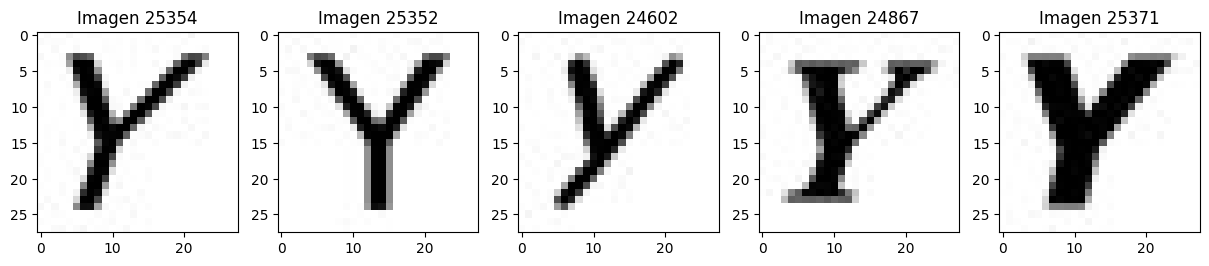

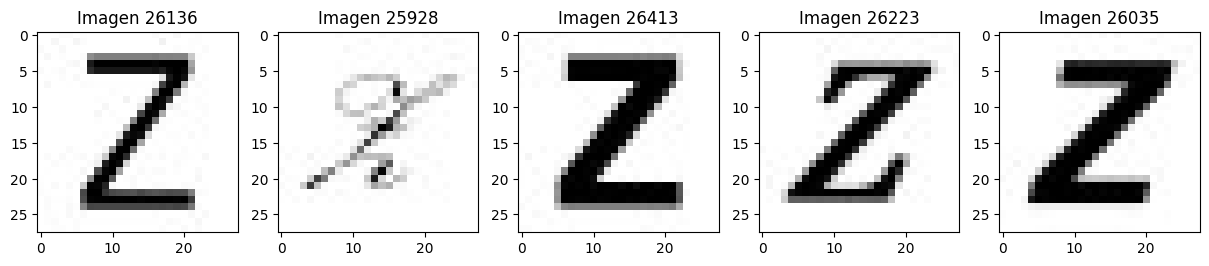

In [6]:
primera_variante_por_letra = {}
j = 0
#Este loop popula el diccionario con la primera variante de cada letra
for i in range(0,26416,1016):
    primera_variante_por_letra[letras[j]] = i
    j += 1

letras_df_sin_label = letras_df.drop(['label'], axis=1) #Necesario para reshape
#Graficamos 5 variantes por letra al azar
np.random.seed(2)
for i in range(0, 26416, 1016):
    # 1. Creamos la figura con 5 subplots (1 fila, 5 columnas)
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    lista_aleatoria = np.random.randint(i, i + 1016, size=5)

    for idx_plot, j in enumerate(lista_aleatoria):
        img = np.array(letras_df_sin_label.iloc[j]).reshape((28,28))

        # Dibujamos en el subplot correspondiente
        axes[idx_plot].imshow(img, cmap='gray')
        axes[idx_plot].set_title(f"Imagen {j}")

    plt.show() # Muestra el gráfico con las 5 letras juntas

Realizado el análisis se considera que los atributos relevantes son los que están más al
'centro' de la matriz donde empiezan a aparecer los pixeles de color negro.
Por lo que se pueden descartar los atributos de las primeras filas y columnas así como las últimas.

En este dataset hay letras más fáciles de diferenciar que otras, por ejemplo, las letras S y M son distinguibles ya que la S consta de líneas curvas mientras que la M de líneas rectas. En cambio las letras O y Q son bastante similares siendo la tilde de la Q lo que principalmente las diferencia.

También hay que tener en cuenta que entre las variantes hay diferencias de tamaño y trazo.

# Experimentos

## Clasificación Binaria
Se busca clasificar una imágen en las categorías O y L. Para esto se
separa un subconjunto del dataset original que contiene las imágenes correspondientes a
la letra O y L. Se verifica que ambas clases se encuentran balanceadas (ya que cada letra
consta de 1016 variantes/imágenes). Posteriormente se separa el subconjunto en train y
test.

In [7]:
# Dataset con las O y las L
letras_OL_df = letras_df[(letras_df['label'] == 14) | (letras_df['label'] == 11)]
letras_OL_df.reset_index(inplace=True, drop=True)

#Separamos train y test
# 'X' son todas las columnas menos 'label'
X = letras_OL_df.drop(columns=['label'])

# 'y' es solo la columna 'label'
y = letras_OL_df['label']
# Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
    stratify=y
)

Para ver qué atributos son relevantes para diferenciar las dos clases (letras), generamos mapas de calor. Para cada clase se calculo el valor promedio de cada pixel.

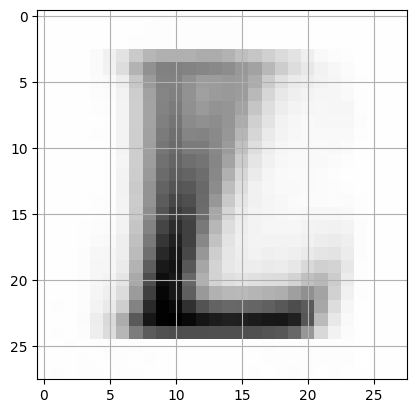

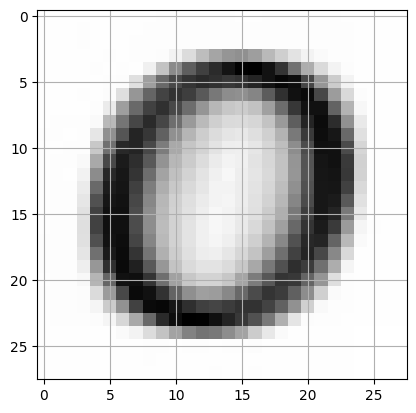

In [26]:
# Creamos mapas de calor para ambas letras
umbral_negro = 170

# Buscamos las O y L's 'promedio'
letras_agrupadas_sum = letras_OL_df.groupby('label').sum() // 1016

img = np.array(letras_agrupadas_sum.iloc[0]).reshape((28,28))
plt.imshow(img, cmap='gray')
plt.grid()
plt.show()

img = np.array(letras_agrupadas_sum.iloc[1]).reshape((28,28))
plt.imshow(img, cmap='gray')
plt.grid()
plt.show()

En ambos gráficos se observa que
hay una gran diferencia entre las filas 10 y 15 y las columnas 20 y 23. Para la letra O hay
atributos con pixel negro mientras que para la letra L son blancos.

Ahora probamos un modelo KNN con 5 vecinos y 3 atributos dentro del rango
mencionado anteriormente.

In [27]:
# Probamos casos
evaluar_y_mostrar_knn([0, 1, 2], 5) #caso de control


# ELegimos 10(filas) * 28(columnas) + 21(columna específica, elegida por mapa)
evaluar_y_mostrar_knn([301, 302, 303], 5) #Elegido por mapa

evaluar_y_mostrar_knn([299, 300, 301], 5) #Desplazado a la izq.

evaluar_y_mostrar_knn([299-28, 300-28, 301-28], 5) #line up

evaluar_y_mostrar_knn([299+28, 300+28, 301+28], 5) #line down

evaluar_y_mostrar_knn([299+56, 300+56, 301+56], 5) # 2 line down


*************************
knn con pixeles [0, 1, 2] y k=5
Exactitud: 0.622
matriz de confusion:
[[172  32]
 [122  81]]
_________________________
*************************
knn con pixeles [301, 302, 303] y k=5
Exactitud: 0.924
matriz de confusion:
[[193  11]
 [ 20 183]]
_________________________
*************************
knn con pixeles [299, 300, 301] y k=5
Exactitud: 0.953
matriz de confusion:
[[197   7]
 [ 12 191]]
_________________________
*************************
knn con pixeles [271, 272, 273] y k=5
Exactitud: 0.951
matriz de confusion:
[[194  10]
 [ 10 193]]
_________________________
*************************
knn con pixeles [327, 328, 329] y k=5
Exactitud: 0.946
matriz de confusion:
[[197   7]
 [ 15 188]]
_________________________
*************************
knn con pixeles [355, 356, 357] y k=5
Exactitud: 0.948
matriz de confusion:
[[197   7]
 [ 14 189]]
_________________________


(0.9484029484029484,
 array([[197,   7],
        [ 14, 189]]))

In [28]:
"""Como detectamos que los atributos 299, 300, 301 eran la mejor elección
según las métricas, probamos ampliando la cantidad de atributos a 7"""
evaluar_y_mostrar_knn([i for i in range(297,304)], 5)

# Mejoraron las métricas, ampliamos atributos a 11
evaluar_y_mostrar_knn([i for i in range(295,306)], 5)

# Mejoraron las métricas, ampliamos atributos a 15
evaluar_y_mostrar_knn([i for i in range(293,308)], 5) # Detecta el 100% de las 'L'


*************************
knn con pixeles [297, 298, 299, 300, 301, 302, 303] y k=5
Exactitud: 0.968
matriz de confusion:
[[196   8]
 [  5 198]]
_________________________
*************************
knn con pixeles [295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305] y k=5
Exactitud: 0.983
matriz de confusion:
[[198   6]
 [  1 202]]
_________________________
*************************
knn con pixeles [293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307] y k=5
Exactitud: 0.99
matriz de confusion:
[[200   4]
 [  0 203]]
_________________________


(0.9901719901719902,
 array([[200,   4],
        [  0, 203]]))

Para los distintos conjuntos de 3 atributos, el de los atributos [299, 300, 301] es el que mejor exactitud tiene. Se utilizó este conjunto para
probar modelos KNN con distintos K (entre 1 y 50).

*************************
knn con pixeles [299, 300, 301] y k=1
Exactitud: 0.951
matriz de confusion:
[[193  11]
 [  9 194]]
_________________________
*************************
knn con pixeles [299, 300, 301] y k=2
Exactitud: 0.958
matriz de confusion:
[[201   3]
 [ 14 189]]
_________________________
*************************
knn con pixeles [299, 300, 301] y k=3
Exactitud: 0.961
matriz de confusion:
[[197   7]
 [  9 194]]
_________________________
*************************
knn con pixeles [299, 300, 301] y k=4
Exactitud: 0.951
matriz de confusion:
[[199   5]
 [ 15 188]]
_________________________
*************************
knn con pixeles [299, 300, 301] y k=5
Exactitud: 0.953
matriz de confusion:
[[197   7]
 [ 12 191]]
_________________________
*************************
knn con pixeles [299, 300, 301] y k=6
Exactitud: 0.946
matriz de confusion:
[[199   5]
 [ 17 186]]
_________________________
*************************
knn con pixeles [299, 300, 301] y k=7
Exactitud: 0.951
matriz de con

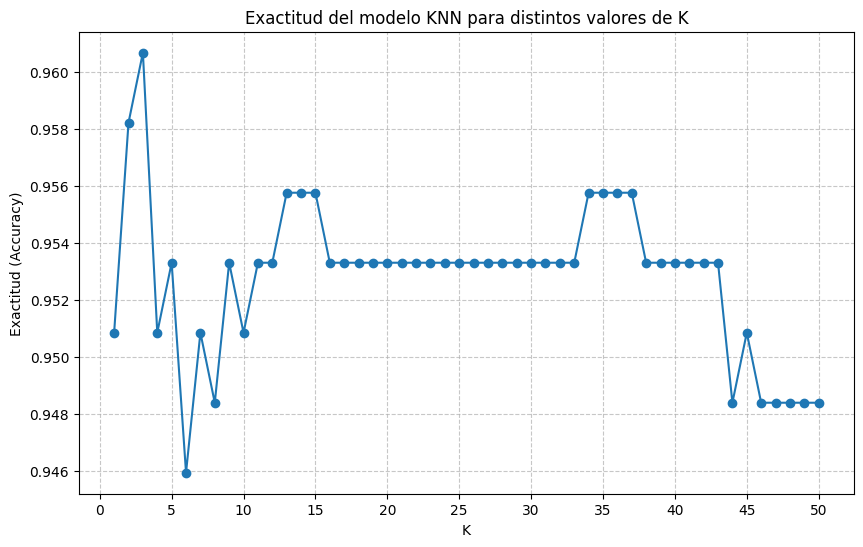

In [30]:
evaluar_distintos_k([299, 300, 301]) #mejor conjunto de 3, distinto k

Se observa que para
este conjunto la cantidad de vecinos (K) que mejor exactitud tienen son 13, 34 y 37 con
0.956 de exactitud.

Se probaron modelos KNN con 7, 11 y 15 atributos y K = 5. Se observó que con 15
atributos (del rango 293-307) la exactitud es del 0.99.
Se decidió usar estos atributos para evaluar con distintos K.

*************************
knn con pixeles [293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307] y k=1
Exactitud: 0.995
matriz de confusion:
[[203   1]
 [  1 202]]
_________________________
*************************
knn con pixeles [293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307] y k=2
Exactitud: 0.99
matriz de confusion:
[[203   1]
 [  3 200]]
_________________________
*************************
knn con pixeles [293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307] y k=3
Exactitud: 0.99
matriz de confusion:
[[200   4]
 [  0 203]]
_________________________
*************************
knn con pixeles [293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307] y k=4
Exactitud: 0.988
matriz de confusion:
[[201   3]
 [  2 201]]
_________________________
*************************
knn con pixeles [293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307] y k=5
Exactitud: 0.99
matriz de confusio

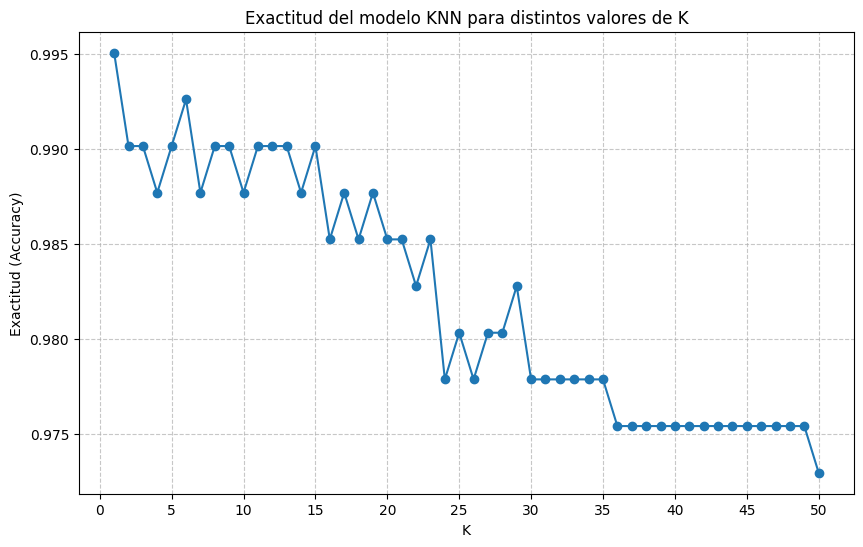

In [31]:
# Probamos distintos K's y más atributos
evaluar_distintos_k([i for i in range(293,308)]) #los 15 atributos de antes


Se observa que para este conjunto la cantidad de vecinos (K) que mejor exactitud tiene es 1 con 0.995 de exactitud.

## Clasificación Multiclase
Se busca clasificar imágenes en clases del dataset que representan las
letras del alfabeto inglés. Para esto se separa el conjunto de datos en desarollo (dev) y
validación (held-out). Para el held-out se separa el 20% de los datos disponibles.

In [8]:
#separamos datos en held-out y dev

# 'X' son todas las columnas menos 'label'
X = letras_df.drop(columns=['label'])

# 'y' es solo la columna 'label'
y = letras_df['label']
# Dividimos los datos
X_dev, X_held_out, y_dev, y_held_out = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
    stratify=y
)

# separamos dev en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_dev,
    y_dev,
    test_size=0.2,
    random_state=2,
    stratify=y_dev
)

Ahora creamos un modelo de árbol de decisión de profundidad 10 con los datos de train.

0.7712325526378045


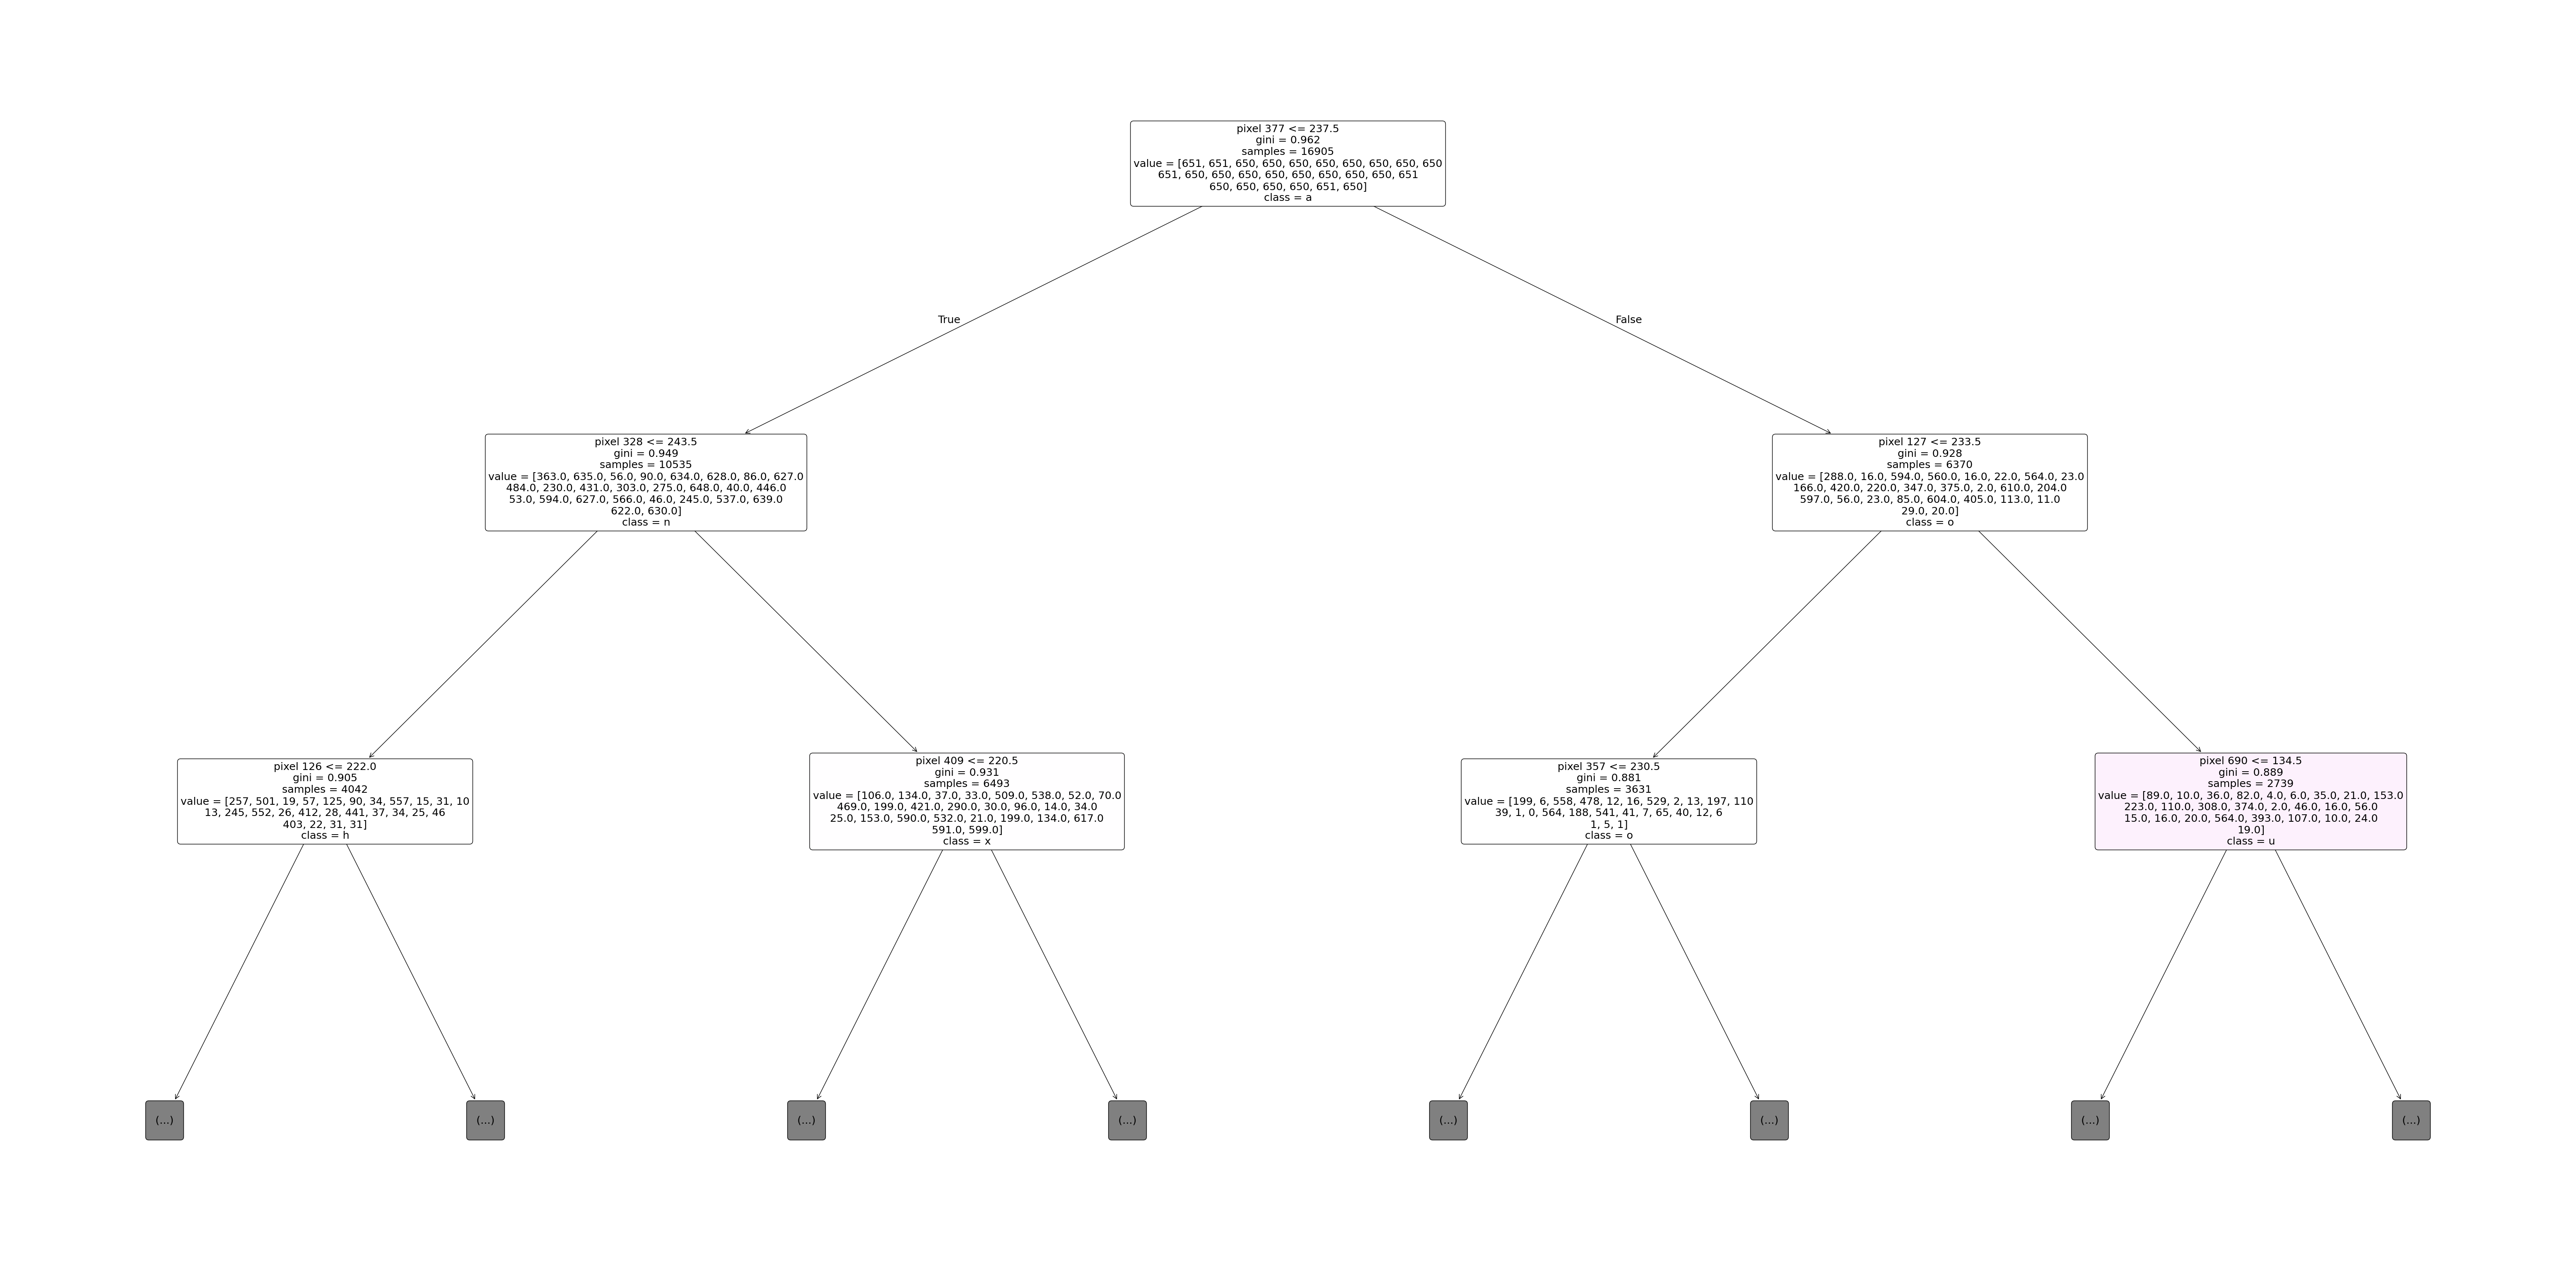

In [9]:
arbol = DecisionTreeClassifier(max_depth=10)
arbol.fit(X_train.values, y_train.values)

y_pred = arbol.predict(X_test.values)
print(accuracy_score(y_test.values, y_pred))
matriz = confusion_matrix(y_test.values, y_pred)
# grafico de las primeras ramas del arbol

plt.figure(figsize=(80,40))
plot_tree(arbol,
          max_depth=2,
          feature_names=X_train.columns,
          class_names=list(letras),
          rounded=True,
          filled=True
          )
plt.show()

Probamos y comparamos distintos modelos según distintas profundidades (entre 1 y 20).

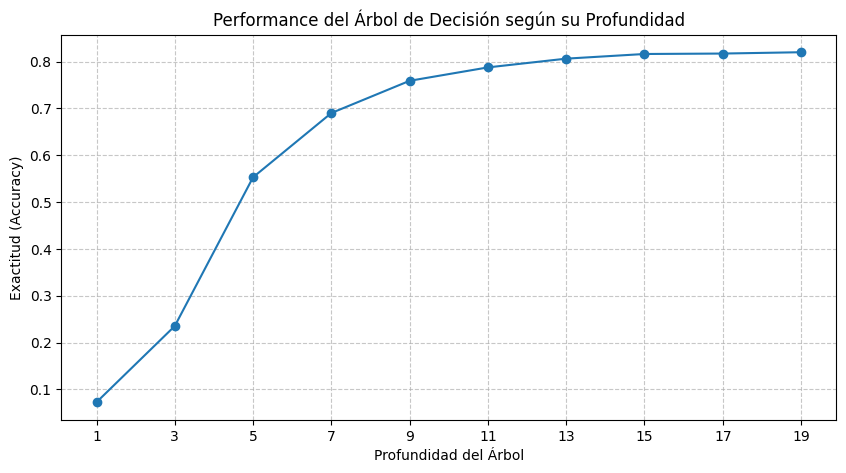

In [35]:
precision = []
profundidad = []

for d in range(1, 21, 2):
    arbol = DecisionTreeClassifier(max_depth=d)
    arbol.fit(X_train.values, y_train.values)
    y_pred = arbol.predict(X_test.values)
    precision.append(accuracy_score(y_test.values, y_pred))
    profundidad.append(d)

plt.figure(figsize=(10, 5))
plt.plot(profundidad, precision, marker='o')

plt.xticks(profundidad)

plt.xlabel('Profundidad del Árbol')
plt.ylabel('Exactitud (Accuracy)')
plt.title('Performance del Árbol de Decisión según su Profundidad')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Se observa que incrementando la profundidad hasta 11 se consigue una exactitud mayor
y a partir de ese punto la curva comienza a aplanarse, indicando una ganancia en exactitud
menor

### K-folding
Vamos a comparar árboles de decisión con distintos hiperparámetos utilizando la técnica de validación cruzada con K-folding usando 5 folds.


Se varían los siguientes hiperparámetros del árbol de decisión:
- Cantidad máxima de atributos de 1 a 121 con incrementos de 10.
- Profundidad máxima del árbol de 1 a 9 con incrementos de 2.
- Criterio de impureza Gini o Entropía.

In [10]:
# Implementación con K-folding
# usamos Stratified para mantener el balance de las 26 letras
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)
resultados = []
criterios = ["gini", "entropy"]
for c in criterios:
    for atributos in range(1, 122, 10):
        for profundidad in range(1, 11, 2):

                arbol = DecisionTreeClassifier(max_depth=profundidad,
                                               max_features=atributos,
                                               random_state=2,
                                               criterion=c
                                               )
                scores = cross_val_score(arbol,
                                         X_dev.values,
                                         y_dev.values,
                                         cv=skf,
                                         scoring='accuracy',
                                         n_jobs=-1) #reparte entre núcleos
                # Guardamos el promedio de las 5 iteraciones
                resultados.append([atributos, profundidad, c, scores.mean()])


arboles_precision_df = pd.DataFrame(resultados,
                                    columns=["atributos",
                                             "profundidad",
                                             "criterio",
                                             "exactitud_promedio"]
                                    )

In [11]:
#solo el maximo de cada uno
for c in criterios:
    mejor_config =( arboles_precision_df.loc[arboles_precision_df[arboles_precision_df["criterio"]==c]['exactitud_promedio'].idxmax()]
                    )
    print("\n--- MEJOR MODELO ENCONTRADO ---")
    print(f"Atributos : {mejor_config['atributos']}")
    print(f"Profundidad : {mejor_config['profundidad']}")
    print(f"Criterio de impureza : {c}")
    print(f"Exactitud media : {float(mejor_config['exactitud_promedio']):.4f}")


--- MEJOR MODELO ENCONTRADO ---
Atributos : 101
Profundidad : 9
Criterio de impureza : gini
Exactitud media : 0.7374

--- MEJOR MODELO ENCONTRADO ---
Atributos : 121
Profundidad : 9
Criterio de impureza : entropy
Exactitud media : 0.7733


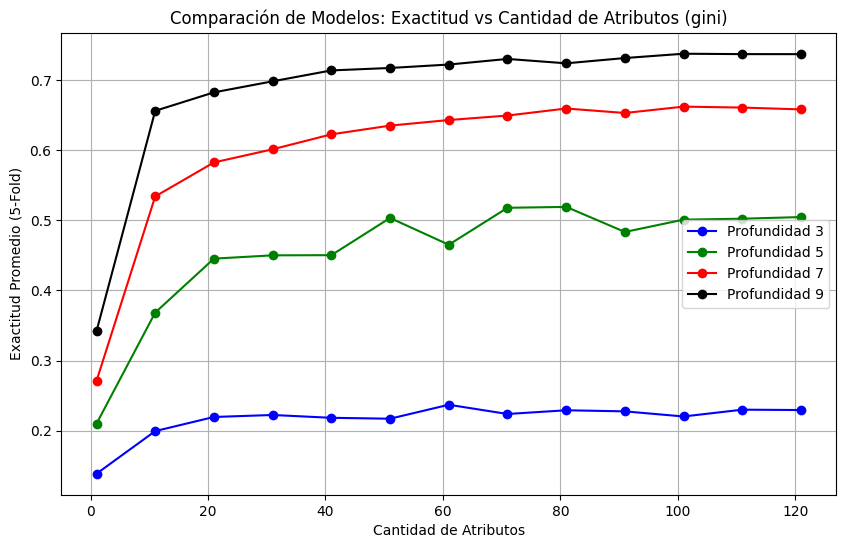

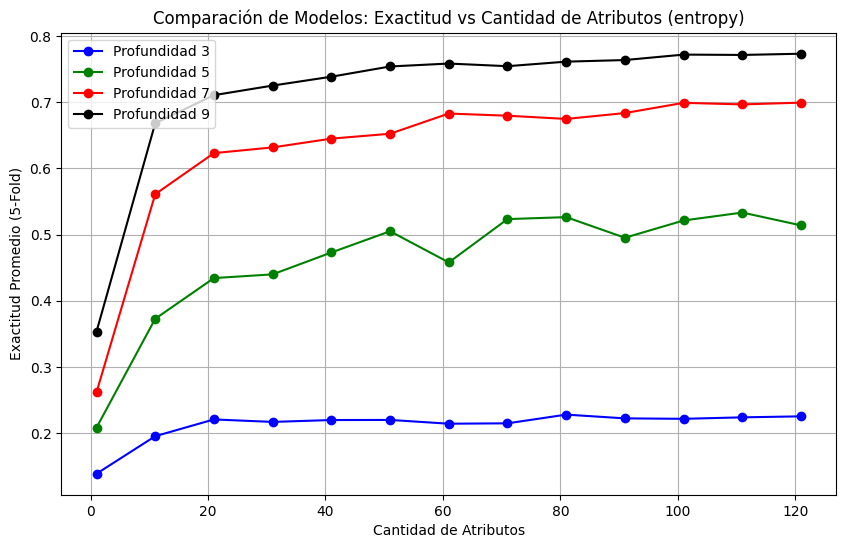

In [12]:
# Gráficos de exactitud según hiperparámetros
colores = ["b", "g", "r", "k"]
for c in criterios:
    plt.figure(figsize=(10, 6))
    for i, prof in enumerate([3, 5, 7, 9]): # Graficamos algunas profundidades para comparar
        data_plot = arboles_precision_df[
            (arboles_precision_df['profundidad'] == prof) &
            (arboles_precision_df['criterio'] == c)
            ]
        plt.plot(data_plot['atributos'],
                 data_plot['exactitud_promedio'],
                 label=f'Profundidad {prof}',
                 marker='o',
                 color=colores[i]
                 )

    plt.title(f'Comparación de Modelos: Exactitud vs Cantidad de Atributos ({c})')
    plt.xlabel('Cantidad de Atributos')
    plt.ylabel('Exactitud Promedio (5-Fold)')
    plt.legend()
    plt.grid(True)
    plt.show()


De estos experimentos se desprende que el mejor modelo es el siguiente:
- Atributos : 121
- Profundidad : 9
- Criterio de impureza : entropy
- Exactitud media : 0.7733

Usamos este modelo para entrenar en el conjunto de desarrollo

Exactitud Final en Held-out: 0.7627


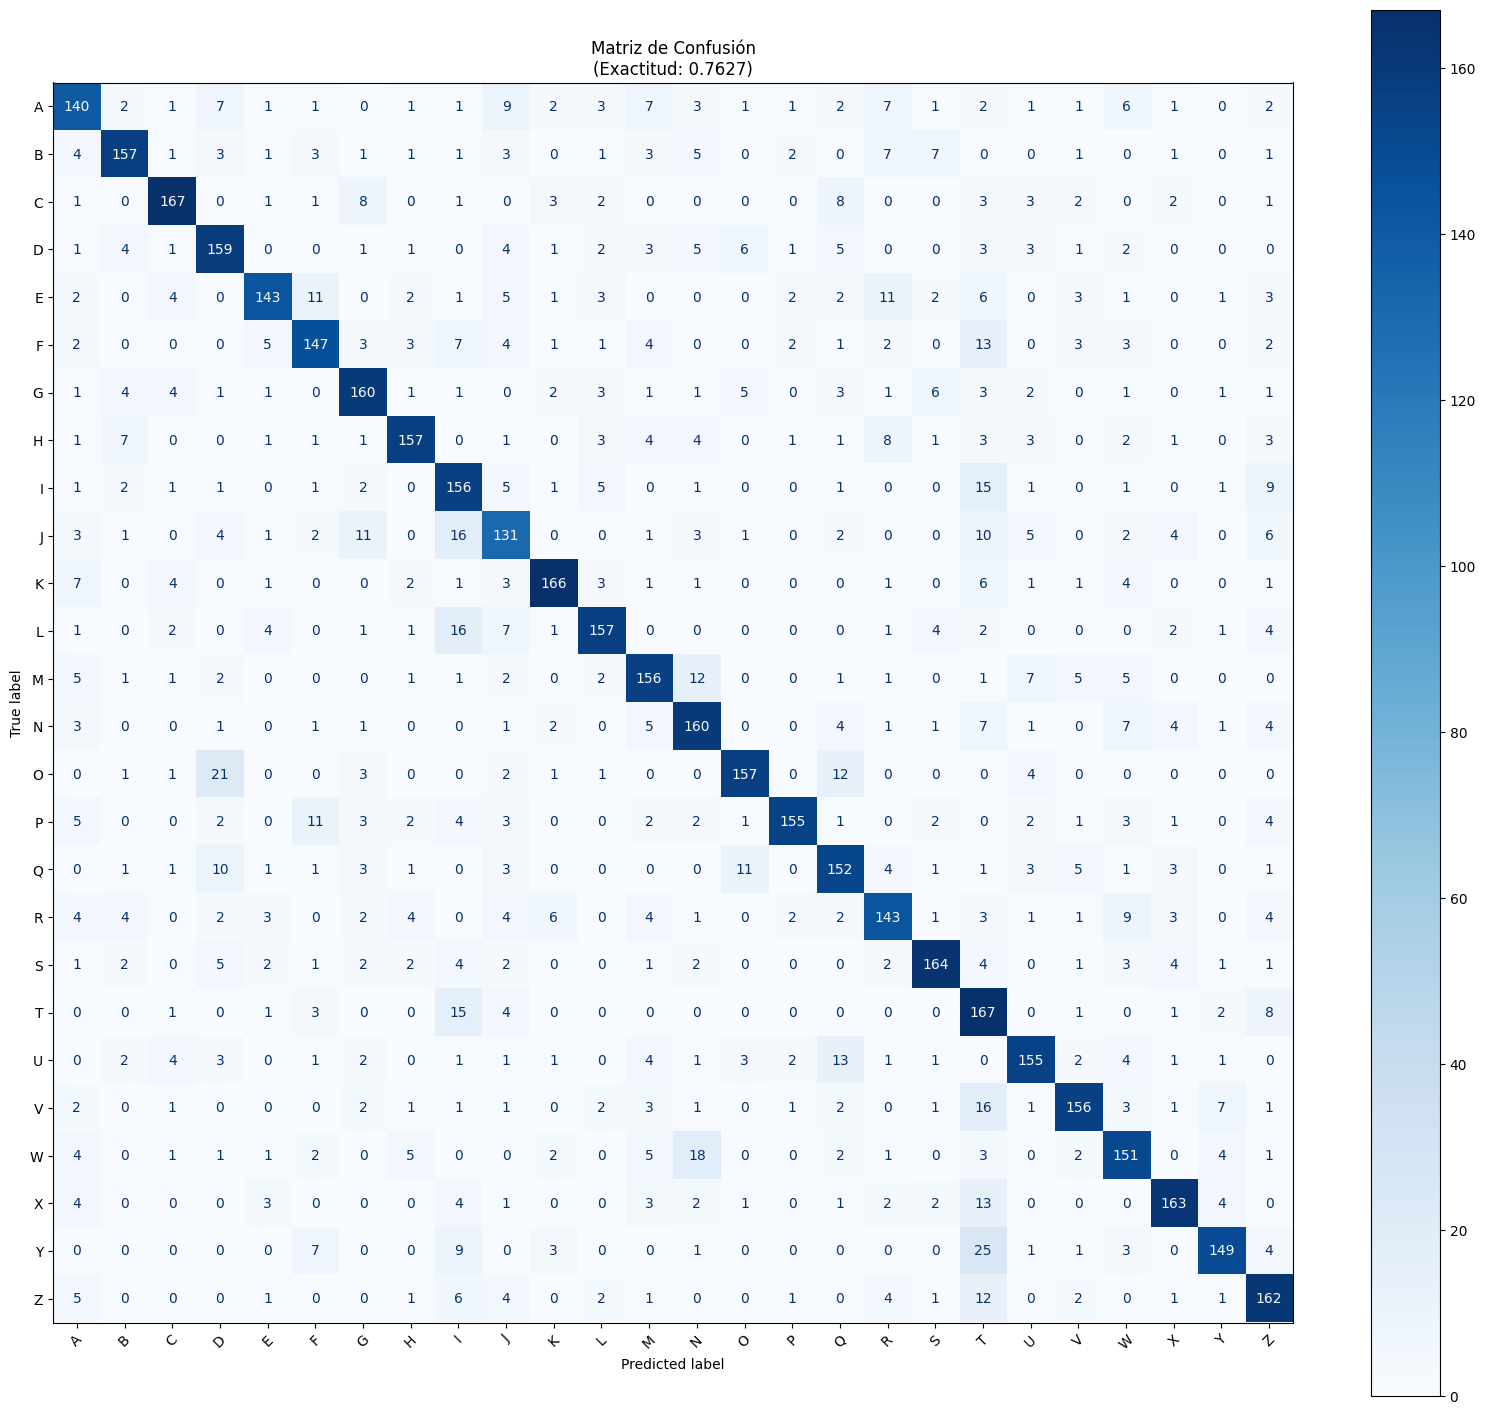

In [13]:
# Definir el mejor modelo según los resultados
mejor_profundidad = 9
mejores_atributos = 121
criterio_impureza = "entropy"

arbol_final = DecisionTreeClassifier(
    max_depth=mejor_profundidad,
    max_features=mejores_atributos,
    random_state=2,
    criterion=criterio_impureza
)

# Entrenar en TODO el conjunto de desarrollo (X_dev, y_dev)
arbol_final.fit(X_dev.values, y_dev.values)

# Predecir las etiquetas del conjunto held-out
y_pred_heldout = arbol_final.predict(X_held_out.values)

# Reportar la performance final
exactitud_final = accuracy_score(y_held_out.values, y_pred_heldout)
print(f"Exactitud Final en Held-out: {exactitud_final:.4f}")

# Matriz de Confusión
cm = confusion_matrix(y_held_out.values, y_pred_heldout)
letras = list(string.ascii_uppercase)

fig, ax = plt.subplots(figsize=(20, 18))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=letras) # no entra en un 'print'
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Matriz de Confusión\n(Exactitud: {exactitud_final:.4f})')
plt.xticks(rotation=45)
plt.show()

Se realizaron predicciones en el conjunto held-out y se
observó la siguiente performance:
- exactitud = 0.7627

Por último, se registraron errores en la matriz de confusión, siendo los
mayores la clasificación de Y como T (25), la O como D (21) y la W como N (18).